In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Problem 2

In [51]:
data1 = pd.read_csv("/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/ps4diag1.csv", header=None)

X = data1.iloc[:, 0]
y = data1.iloc[:, 1]

X_design = sm.add_constant(X)

# fitting full model
model = sm.OLS(y, X_design).fit()

# MSRes 
MSRes_full = model.mse_resid
print("MSRes (full):", MSRes_full)

# removing first observation
X_removed = X_design.iloc[1:]
y_removed = y.iloc[1:]

model_removed = sm.OLS(y_removed, X_removed).fit()
MSRes_removed = model_removed.mse_resid
print("MSRes (without first obs):", MSRes_removed)

influence = model.get_influence()
residuals = model.resid
hat = influence.hat_matrix_diag

n = len(y)
p = X_design.shape[1]  # including intercept
i = 0  
S2_formula = ((n - p) * MSRes_full - (residuals[i]**2) / (1 - hat[i])) / (n - p - 1)

print("S^2_(1) from formula:", S2_formula)

# Compare
print("-----------")
print("Direct recompute:", MSRes_removed)
print("Formula result:", S2_formula)

MSRes (full): 0.21151498188331277
MSRes (without first obs): 0.23661932703150673
S^2_(1) from formula: 0.23661932703150676
-----------
Direct recompute: 0.23661932703150673
Formula result: 0.23661932703150676


### The two values should be very close. It confirms the formula works as an efficient shortcut (no need to refit model)


# Problem 3

In [38]:
data2 = pd.read_csv("/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/ps4diag2.csv", header=None)
X = data2.iloc[:, 0]
y = data2.iloc[:, 1]

X_design = sm.add_constant(X)
model = sm.OLS(y, X_design).fit()

influence = model.get_influence()
hat = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]
covratio = influence.cov_ratio
n = len(y)
p = X_design.shape[1]

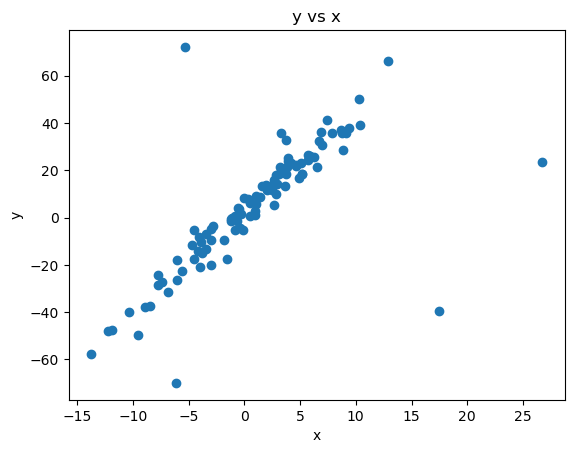

In [39]:
plt.scatter(X, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("y vs x")
plt.show()

In [40]:
lev_threshold = 2 * p / n
lev_points = np.where(hat > lev_threshold)[0]

print("Leverage points:", lev_points)

Leverage points: [ 1  9 22 24 27 53 55]


In [41]:
cooks_threshold = 4 / n
cooks_points = np.where(cooks_d > cooks_threshold)[0]

print("Influential points for Cooks:", cooks_points)

Influential points for Cooks: [ 9 14 24 55 96]


In [42]:
covratio_threshold = 3 * p / n
covratio_points = np.where(np.abs(covratio - 1) > covratio_threshold)[0]

print("Influential points for covratio:", covratio_points)

Influential points for covratio: [ 1 14 22 24 27 55 96]


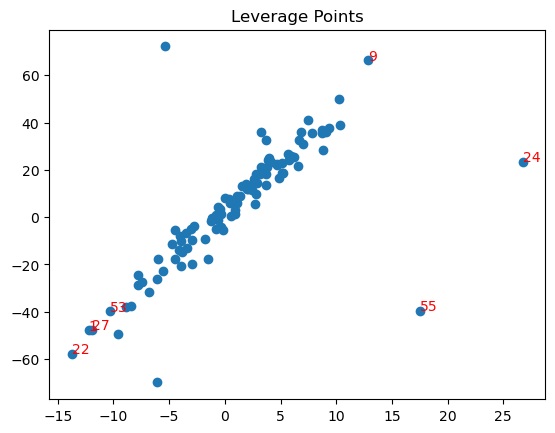

In [43]:
plt.scatter(X, y)

for i in lev_points:
    plt.text(X[i], y[i], str(i), color='red')

plt.title("Leverage Points")
plt.show()

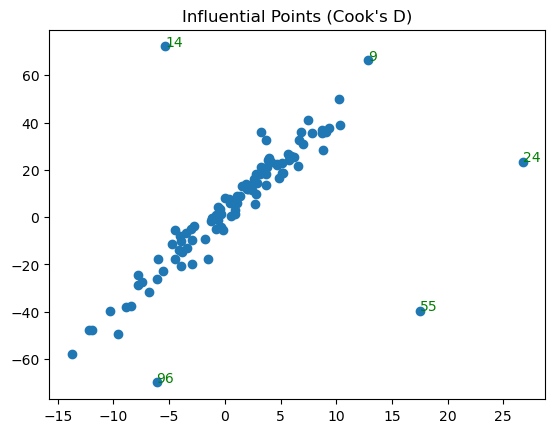

In [44]:
plt.scatter(X, y)

for i in cooks_points:
    plt.text(X[i], y[i], str(i), color='green')

plt.title("Influential Points (Cook's D)")
plt.show()

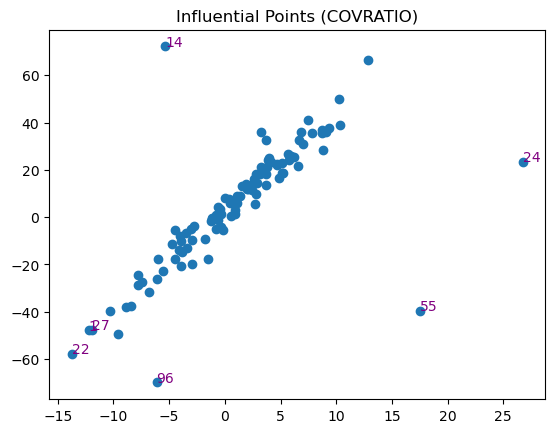

In [45]:
plt.scatter(X, y)

for i in covratio_points:
    plt.text(X[i], y[i], str(i), color='purple')

plt.title("Influential Points (COVRATIO)")
plt.show()

# Problem 4

In [46]:
data3 = pd.read_csv("/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/ps4diag3.csv", header=None)
X = data3.iloc[:, 0]
y = data3.iloc[:, 1]

X_design = sm.add_constant(X)
model = sm.OLS(y, X_design).fit()

influence = model.get_influence()
hat = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]
covratio = influence.cov_ratio

n = len(y)
p = X_design.shape[1]

# Leverage
leverage_points = np.where(hat > (2*p/n))[0]

# Cook's D
cooks_points = np.where(cooks_d > (4/n))[0]

# COVRATIO
covratio_points = np.where(np.abs(covratio - 1) > (3*p/n))[0]


print("Leverage:", leverage_points)
print("Cook's D:", cooks_points)
print("COVRATIO:", covratio_points)

Leverage: [22]
Cook's D: [95]
COVRATIO: [22 95]


In [47]:
# results with fixed indexing
print("Leverage points (1-based):", leverage_points + 1)
print("Cook's D influential points (1-based):", cooks_points + 1)
print("COVRATIO influential points (1-based):", covratio_points + 1)

Leverage points (1-based): [23]
Cook's D influential points (1-based): [96]
COVRATIO influential points (1-based): [23 96]


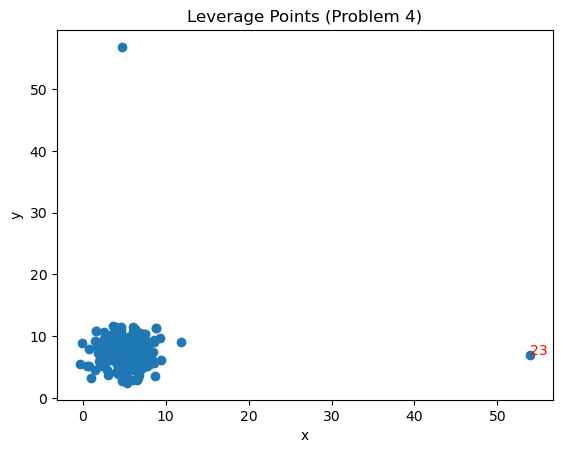

In [48]:
plt.scatter(X, y)

for i in leverage_points:
    plt.text(X[i], y[i], str(i+1), color='red')

plt.title("Leverage Points (Problem 4)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

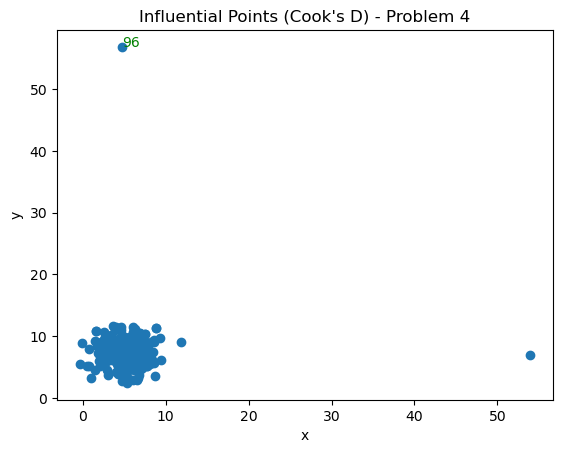

In [49]:
plt.scatter(X, y)

for i in cooks_points:
    plt.text(X[i], y[i], str(i+1), color='green')

plt.title("Influential Points (Cook's D) - Problem 4")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

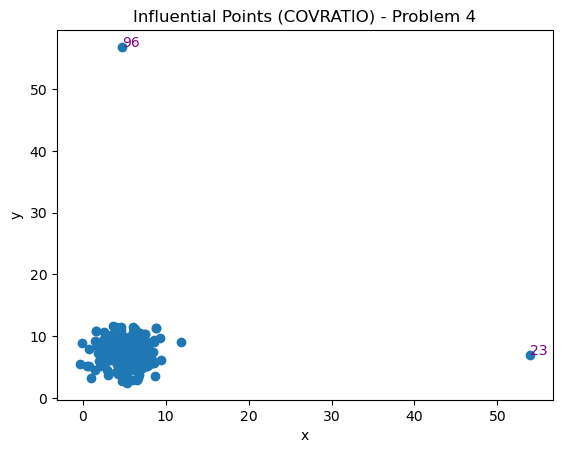

In [50]:
plt.scatter(X, y)

for i in covratio_points:
    plt.text(X[i], y[i], str(i+1), color='purple')

plt.title("Influential Points (COVRATIO) - Problem 4")
plt.xlabel("x")
plt.ylabel("y")
plt.show()